# HRRR Precipitation Forecast Download

This notebook demonstrates how to download and process HRRR (High-Resolution Rapid Refresh) precipitation forecast data using the `PrecipHrrr` class in ras-commander.

**HRRR** is NOAA's operational numerical weather prediction model with:
- **3km horizontal resolution** over CONUS
- **Hourly forecast cycles** (00z through 23z)
- **18-hour forecast horizon** for standard cycles
- **48-hour forecast horizon** for extended cycles (00z, 06z, 12z, 18z)
- **Data source**: NOAA NOMADS server (publicly available, no account required)

**Series position:** This is a focused input-data drill-down for the operational forecast sequence. Start with `915_realtime_forecast_workflow.ipynb` for the full workflow, then use this notebook when you need the HRRR precipitation forcing details.

HRRR is particularly valuable for:
- Short-range flood forecasting
- Real-time operational HEC-RAS model forcing
- Ensemble precipitation inputs for hydraulic models

## Setup and Imports

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
# Set USE_LOCAL_SOURCE based on your setup:
#   True  = Use local source code (for developers editing ras-commander)
#   False = Use pip-installed package (for users)
# =============================================================================

USE_LOCAL_SOURCE = True  # <-- TOGGLE THIS

# -----------------------------------------------------------------------------
if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    local_path = str(Path.cwd().parent)  # Parent of examples/ = repo root
    if local_path not in sys.path:
        sys.path.insert(0, local_path)  # Insert at position 0 = highest priority
    print("LOCAL SOURCE MODE: Loading repository ras_commander")
else:
    print("PIP PACKAGE MODE: Loading installed ras-commander")

# Verify which version loaded without retaining environment-specific paths.
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="IProgress not found.*",
        category=Warning,
        module=r"tqdm\.auto",
    )
    import ras_commander
source_label = "local source" if USE_LOCAL_SOURCE else "installed package"
print(f"Loaded ras-commander {ras_commander.__version__} from {source_label}")

LOCAL SOURCE MODE: Loading repository ras_commander


Loaded ras-commander 0.98.2 from local source


In [2]:
from datetime import datetime, timedelta
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ras_commander.precip import PrecipHrrr

logging.getLogger("ras_commander.precip.PrecipHrrr").setLevel(logging.WARNING)

print("Imports complete.")

Imports complete.


## What You'll Learn

- How to query HRRR data availability on NOAA NOMADS
- How to download the latest HRRR forecast cycle automatically
- How to download a specific date and cycle
- How to extract precipitation data from GRIB2 files to xarray
- How to compute basin-average precipitation time series
- HRRR cycle timing and forecast horizon reference

## HRRR Overview

The High-Resolution Rapid Refresh (HRRR) model runs every hour at 3km resolution. Understanding cycle timing and data latency is important for operational use:

| Cycle | Type | Forecast Horizon | Typical Availability |
|-------|------|-----------------|---------------------|
| 00z, 06z, 12z, 18z | Extended | 48 hours | ~2 hours after cycle |
| All other hours | Standard | 18 hours | ~2 hours after cycle |

**File format**: GRIB2 (`.grib2`)

**Key precipitation variable**: `APCP` (Accumulated Precipitation, kg/m²)

**Data server**: [NOAA NOMADS](https://nomads.ncep.noaa.gov/pub/data/nccf/com/hrrr/prod/)

**Retention**: NOMADS retains approximately 48 hours of recent HRRR output. For archived HRRR data, use the NOAA HRRR archive on AWS.

In [3]:
# Get HRRR system information
info = PrecipHrrr.get_info()
print("HRRR System Information:")
print(f"  Data source: {info.get('base_url', 'NOAA NOMADS')}")
print(f"  Resolution: {info.get('spatial_resolution', '3km')}")
print(f"  Standard forecast: {info.get('forecast_horizon_standard', '18 hours')}")
print(f"  Extended forecast: {info.get('forecast_horizon_extended', '48 hours')}")
print(f"  Update frequency: {info.get('update_frequency', 'Hourly')}")
print(f"  CONUS bounds: {info.get('bounds', 'Full CONUS')}")

HRRR System Information:
  Data source: https://nomads.ncep.noaa.gov/pub/data/nccf/com/hrrr/prod
  Resolution: 3 km
  Standard forecast: 18 hours
  Extended forecast: 48 hours (00z, 06z, 12z, 18z cycles)
  Update frequency: Hourly (every cycle)
  CONUS bounds: (-134.1, 21.1, -60.9, 52.6)


## Example 1: Single Forecast Cycle

In this example we use `get_latest_forecast()` to automatically find and download the most recent available HRRR cycle. This is the recommended approach for operational workflows.

### Check Availability

Before downloading, verify that the desired HRRR cycle is available on NOMADS. This is useful for operational monitoring and retry logic.

In [4]:
# Live network failures are intentional notebook failures.
available = PrecipHrrr.check_availability()
print(f"Latest HRRR cycle available: {available}")

yesterday = datetime.now() - timedelta(days=1)
available_12z = PrecipHrrr.check_availability(
    date=yesterday.strftime("%Y-%m-%d"),
    cycle=12,
)
print(f"Yesterday's 12z cycle available: {available_12z}")
print(f"  (Checked date: {yesterday.strftime('%Y-%m-%d')})")

Latest HRRR cycle available: True
Yesterday's 12z cycle available: True
  (Checked date: 2026-07-09)


### Download Latest HRRR Forecast

`get_latest_forecast()` searches backwards through recent cycles (controlled by `max_lookback_hours`) to find the most recently published HRRR data. This handles the ~2 hour latency between cycle time and data availability.

In [5]:
# Download latest HRRR cycle (18 hours ahead)
output_dir = Path("example_data/hrrr_single")
output_dir.mkdir(parents=True, exist_ok=True)

grib_files = PrecipHrrr.get_latest_forecast(
    output_dir=output_dir,
    hours=18,
    max_lookback_hours=6,
)
if len(grib_files) != 18:
    raise RuntimeError(f"Expected 18 HRRR files; received {len(grib_files)}")

total_gb = sum(path.stat().st_size for path in grib_files) / (1024 ** 3)
print(f"Downloaded {len(grib_files)} GRIB2 files ({total_gb:.2f} GB total)")
print("First and last files:")
for path in (grib_files[0], grib_files[-1]):
    size_mb = path.stat().st_size / (1024 ** 2)
    print(f"  {path.name} ({size_mb:.0f} MB)")

Downloaded 18 GRIB2 files (3.40 GB total)
First and last files:
  hrrr.t16z.wrfsubhf01.grib2 (199 MB)
  hrrr.t16z.wrfsubhf18.grib2 (176 MB)


### Extract Precipitation Data

`extract_precipitation()` reads the GRIB2 files and returns an `xarray.Dataset` containing the precipitation variable(s). An optional `bounds` parameter (west, south, east, north) clips the data to a region of interest, which significantly reduces memory usage.

In [6]:
# Extract precipitation for Bald Eagle Creek, Pennsylvania.
bounds = (-77.9, 40.8, -77.3, 41.1)  # west, south, east, north
precip_ds = PrecipHrrr.extract_precipitation(
    grib_files=grib_files,
    bounds=bounds,
)

valid_times = pd.DatetimeIndex(pd.to_datetime(precip_ds["valid_time"].values))
cadence = valid_times.to_series().diff().dropna().unique()
if len(cadence) != 1 or cadence[0] != pd.Timedelta(minutes=15):
    raise RuntimeError(f"Expected a uniform 15-minute HRRR cadence; found {cadence}")
if precip_ds.sizes.get("step") != len(valid_times):
    raise RuntimeError("HRRR step dimension and valid-time coordinate do not align")

print("Extracted precipitation dataset:")
print(f"  Variables: {list(precip_ds.data_vars)}")
print(f"  Dimensions: {dict(precip_ds.sizes)}")
print(f"  Records: {len(valid_times)} at 15-minute cadence")
print(f"  Valid-time coverage: {valid_times[0]} through {valid_times[-1]}")
print(f"  Regional bounds: {bounds}")

Extracted precipitation dataset:
  Variables: ['tp']
  Dimensions: {'step': 72, 'y': 15, 'x': 18}
  Records: 72 at 15-minute cadence
  Valid-time coverage: 2026-07-10 16:15:00 through 2026-07-11 10:00:00
  Regional bounds: (-77.9, 40.8, -77.3, 41.1)


### Basin-Average Precipitation

`get_basin_average()` spatially averages the gridded HRRR precipitation over a watershed geometry. The `wrfsubhf` files used here contain four quarter-hour records per forecast hour, so the returned row index is aligned to the dataset's actual `valid_time` coordinate before interpretation. The geometry can be any Shapely geometry (polygon, multipolygon, etc.).

The returned DataFrame has columns:
- `valid_time` - Actual UTC timestamp supplied by the HRRR dataset
- `precip_mm` - Incremental precipitation in millimeters
- `precip_inches` - Incremental precipitation in inches
- `cumulative_mm` - Cumulative precipitation in millimeters
- `cumulative_inches` - Cumulative precipitation in inches

Basin-average precipitation: showing 12 of 72 records


,valid_time,precip_mm,precip_inches,cumulative_mm,cumulative_inches
0,2026-07-10 16:15:00,0.0000,0.00000,0.000,0.000
1,2026-07-10 16:30:00,0.0000,0.00000,0.000,0.000
2,2026-07-10 16:45:00,0.0000,0.00000,0.000,0.000
3,2026-07-10 17:00:00,0.0000,0.00000,0.000,0.000
4,2026-07-10 17:15:00,0.0001,0.00000,0.000,0.000
5,2026-07-10 17:30:00,0.0001,0.00001,0.000,0.000
66,2026-07-11 08:45:00,0.0000,0.00000,9.368,0.369
67,2026-07-11 09:00:00,0.0000,0.00000,9.368,0.369
68,2026-07-11 09:15:00,0.0000,0.00000,9.368,0.369
69,2026-07-11 09:30:00,0.0000,0.00000,9.368,0.369


Total forecast precipitation: 0.369 inches
Peak 15-minute precipitation: 0.042 inches at 2026-07-10 23:00:00


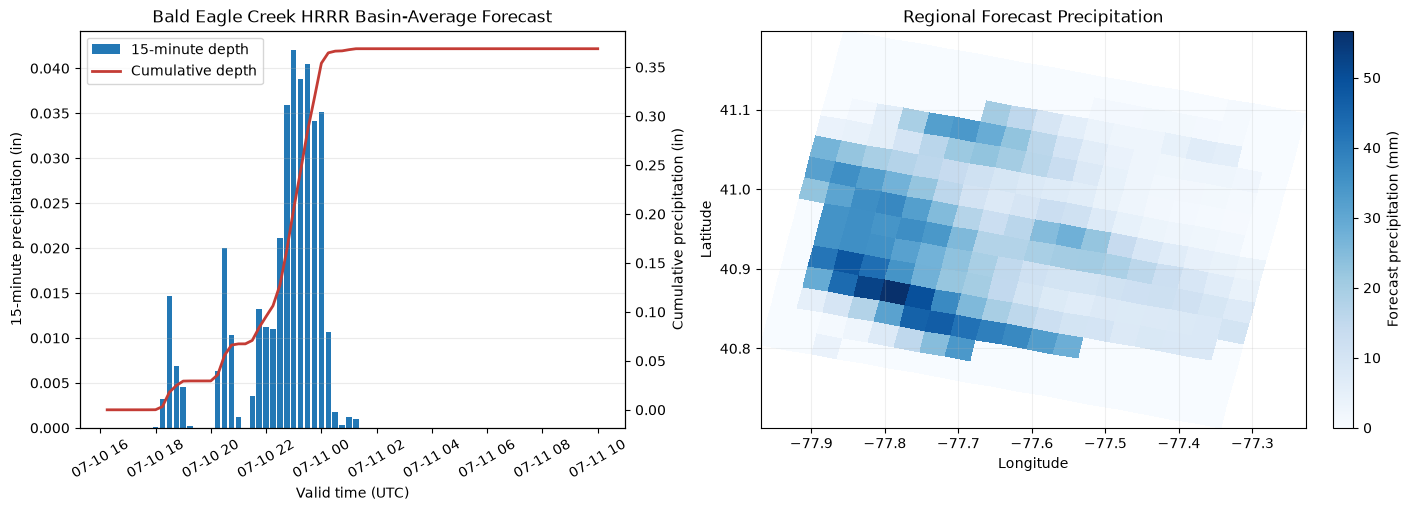

In [7]:
from shapely.geometry import box

basin_geom = box(*bounds)
avg_precip = PrecipHrrr.get_basin_average(
    grib_files=grib_files,
    geometry=basin_geom,
)
if len(avg_precip) != len(valid_times):
    raise RuntimeError(
        f"Basin-average rows ({len(avg_precip)}) do not match HRRR records ({len(valid_times)})"
    )

avg_precip = avg_precip.drop(columns=["forecast_hour"]).copy()
avg_precip.insert(0, "valid_time", valid_times)
preview = pd.concat([avg_precip.head(6), avg_precip.tail(6)]).drop_duplicates()
print(f"Basin-average precipitation: showing {len(preview)} of {len(avg_precip)} records")
display(
    preview.style.format(
        {
            "precip_mm": "{:.4f}",
            "precip_inches": "{:.5f}",
            "cumulative_mm": "{:.3f}",
            "cumulative_inches": "{:.3f}",
        }
    )
)
print(f"Total forecast precipitation: {avg_precip['cumulative_inches'].iloc[-1]:.3f} inches")
print(
    f"Peak 15-minute precipitation: {avg_precip['precip_inches'].max():.3f} inches "
    f"at {avg_precip.loc[avg_precip['precip_inches'].idxmax(), 'valid_time']}"
)

fig, (ax_hyetograph, ax_map) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
ax_hyetograph.bar(
    avg_precip["valid_time"],
    avg_precip["precip_inches"],
    width=pd.Timedelta(minutes=12),
    color="#2378b5",
    label="15-minute depth",
)
ax_cumulative = ax_hyetograph.twinx()
ax_cumulative.plot(
    avg_precip["valid_time"],
    avg_precip["cumulative_inches"],
    color="#c43c35",
    linewidth=2,
    label="Cumulative depth",
)
ax_hyetograph.set(
    title="Bald Eagle Creek HRRR Basin-Average Forecast",
    xlabel="Valid time (UTC)",
    ylabel="15-minute precipitation (in)",
)
ax_cumulative.set_ylabel("Cumulative precipitation (in)")
handles_1, labels_1 = ax_hyetograph.get_legend_handles_labels()
handles_2, labels_2 = ax_cumulative.get_legend_handles_labels()
ax_hyetograph.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper left")
ax_hyetograph.tick_params(axis="x", rotation=30)
ax_hyetograph.grid(axis="y", alpha=0.25)

total_grid = precip_ds["tp"].sum(dim="step", skipna=True)
plot_longitude = ((precip_ds["longitude"] + 180.0) % 360.0) - 180.0
image = ax_map.pcolormesh(
    plot_longitude,
    precip_ds["latitude"],
    total_grid,
    shading="auto",
    cmap="Blues",
)
ax_map.set(
    title="Regional Forecast Precipitation",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax_map.grid(alpha=0.2)
fig.colorbar(image, ax=ax_map, label="Forecast precipitation (mm)")
plt.show()

## Example 2: Specific Date/Cycle Download

When you need a specific historical cycle (within NOMADS retention window, typically ~48 hours), use `download_forecast()` with explicit `date` and `cycle` parameters. This is useful for:
- Comparing model forecasts to observations after an event
- Reproducible analysis with a known dataset
- Operational post-processing pipelines

In [8]:
# Download a specific date and cycle
output_dir_specific = Path("example_data/hrrr_specific")
output_dir_specific.mkdir(parents=True, exist_ok=True)

# Use yesterday's 00z cycle with 18-hour forecast
yesterday = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")

grib_files_specific = PrecipHrrr.download_forecast(
    output_dir=output_dir_specific,
    date=yesterday,
    cycle=0,
    hours=18,
    overwrite=False,
)
if len(grib_files_specific) != 18:
    raise RuntimeError(f"Expected 18 HRRR files; received {len(grib_files_specific)}")
total_gb_specific = sum(path.stat().st_size for path in grib_files_specific) / (1024 ** 3)
print(f"Downloaded 18 files for {yesterday} 00Z ({total_gb_specific:.2f} GB total)")

Downloaded 18 files for 2026-07-09 00Z (3.39 GB total)


### HRRR Cycle Timing Reference

Understanding HRRR cycle timing is critical for operational use. The following cell provides a reference table for all 24 daily cycles.

In [9]:
# HRRR cycles and forecast horizons (all 24 hourly cycles)
print("HRRR Forecast Cycles:")
print("=" * 65)
print(f"{'Cycle':<10} {'Type':<12} {'Forecast Hours':<20} {'Approx Availability (UTC)'}")
print("-" * 65)

EXTENDED_CYCLES = [0, 6, 12, 18]

for cycle in range(0, 24):
    if cycle in EXTENDED_CYCLES:
        cycle_type = "Extended"
        hours = "48 hours"
    else:
        cycle_type = "Standard"
        hours = "18 hours"
    avail_hour = (cycle + 2) % 24
    availability = f"{avail_hour:02d}:00 - {avail_hour:02d}:30 UTC"
    print(f"{cycle:02d}z       {cycle_type:<12} {hours:<20} {availability}")

print()
print("Notes:")
print("  - HRRR runs every hour (24 cycles per day, 00z through 23z)")
print("  - Data typically available ~2 hours after cycle start time")
print("  - Example: 12z cycle data available ~14:00 UTC")
print("  - Extended cycles (00/06/12/18z) produce 48-hour forecasts")
print("  - All other cycles produce 18-hour forecasts")
print("  - NOMADS retains ~48 hours of recent cycles")
print("  - For older data: https://storage.googleapis.com/high-resolution-rapid-refresh/")
print()
print("File size reference (full CONUS wrfsubhf):")
print("  File sizes vary by cycle and HRRR product; this live run reports observed totals above")
print("  Current wrfsubhf files are commonly about 200 MB each")
print("  Budget roughly 3-4 GB for an 18-hour full-CONUS wrfsubhf cycle")
print("  Spatial subsetting via 'bounds' parameter reduces size significantly")

HRRR Forecast Cycles:
Cycle      Type         Forecast Hours       Approx Availability (UTC)
-----------------------------------------------------------------
00z       Extended     48 hours             02:00 - 02:30 UTC
01z       Standard     18 hours             03:00 - 03:30 UTC
02z       Standard     18 hours             04:00 - 04:30 UTC
03z       Standard     18 hours             05:00 - 05:30 UTC
04z       Standard     18 hours             06:00 - 06:30 UTC
05z       Standard     18 hours             07:00 - 07:30 UTC
06z       Extended     48 hours             08:00 - 08:30 UTC
07z       Standard     18 hours             09:00 - 09:30 UTC
08z       Standard     18 hours             10:00 - 10:30 UTC
09z       Standard     18 hours             11:00 - 11:30 UTC
10z       Standard     18 hours             12:00 - 12:30 UTC
11z       Standard     18 hours             13:00 - 13:30 UTC
12z       Extended     48 hours             14:00 - 14:30 UTC
13z       Standard     18 hours    

## Key Takeaways

**HRRR Data Characteristics**:
- 3km resolution, hourly cycles, publicly available from NOAA NOMADS
- Standard cycles produce 18-hour forecasts; extended cycles (00/06/12/18z) produce 48-hour forecasts
- NOMADS retains approximately 48 hours of recent output; use the HRRR archive on AWS for older data

**Workflow Summary**:
1. Use `check_availability()` to verify data is on NOMADS before downloading
2. Use `get_latest_forecast()` for operational workflows that always need current data
3. Use `download_forecast(date=..., cycle=...)` when you need a specific historical cycle
4. Use `extract_precipitation(bounds=...)` to clip to your region of interest (reduces memory)
5. Use `get_basin_average()` to compute watershed-averaged precipitation for HEC-RAS boundary conditions

**Common Pitfalls**:
- APCP timing depends on the HRRR product and record metadata. The `wrfsubhf` records used above are 15-minute intervals; the qpkit `wrfsfc` workflow differences running accumulations into one-hour DSS depths. Always validate `step` and `valid_time` before summing.
- The `overwrite=False` default prevents redundant downloads in operational pipelines
- For production use, cache GRIB2 files locally and size storage from observed files; this run reports its actual total rather than assuming a fixed download size.
- cfgrib and eccodes are required for `extract_precipitation()`: `uv pip install cfgrib eccodes`

**Integration with HEC-RAS**:
- Use `get_basin_average()` output as upstream boundary condition hyetographs
- Combine with `RasUnsteady.set_precipitation_hyetograph()` to write directly to unsteady flow files
- For spatially distributed rainfall, export `extract_precipitation()` output to DSS using `RasDss`

## Cleanup

In [10]:
import shutil

for d in ["example_data/hrrr_single", "example_data/hrrr_specific"]:
    p = Path(d)
    if p.exists():
        shutil.rmtree(p)
        print(f"Cleaned up: {d}")
    else:
        print(f"Not found (nothing to clean): {d}")

print("Done!")

Cleaned up: example_data/hrrr_single


Cleaned up: example_data/hrrr_specific
Done!


## Optional: Write a Live HRRR Forecast to DSS with qpkit

This additive workflow uses `qpkit` v0.1.0 to download a regional HRRR APCP forecast and write one-hour incremental precipitation grids to HEC-DSS. Install the optional dependency from a terminal at the repository root before running these cells:

```console
uv pip install "git+https://github.com/gyanz/qpkit.git@v0.1.0"
```

The cycle selection is live rather than date-pinned. It probes NOMADS for the latest published HRRR f00 file, then selects the cycle six hours earlier so the requested f00 through f06 files are likely complete. This is still a live network workflow: NOAA availability, `pydsstools` support, and a Java runtime for `RasDss.get_catalog()` are required. Any missing file, failed grid write, or catalog mismatch raises an exception.

All generated GRIB2 and DSS files go under the repository's ignored `working/` directory. A unique run folder makes the DSS write fresh and keeps the existing examples and outputs above unchanged.

In [11]:
from datetime import datetime, timedelta, timezone
from importlib.metadata import version as package_version
from pathlib import Path
import logging
import warnings

for logger_name in (
    "httpx",
    "pydsstools",
    "pydsstools.heclib.logging",
    "rasterio",
    "rasterio._env",
    "rasterio._err",
):
    logging.getLogger(logger_name).setLevel(logging.WARNING)

from qpkit import BoundingBox, HRRRGridOptions, HRRRRequest, QPKit

QPKIT_VERSION = package_version("qpkit")
if QPKIT_VERSION != "0.1.0":
    raise RuntimeError(f"This workflow requires qpkit 0.1.0; found {QPKIT_VERSION}")

qpkit_logger = logging.getLogger("qpkit")
qpkit_logger.setLevel(logging.WARNING)

repo_root = Path.cwd()
if repo_root.name.lower() == "examples":
    repo_root = repo_root.parent

run_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
hrrr_run_root = repo_root / "working" / "example_916_qpkit_hrrr_to_dss" / run_stamp
hrrr_grib_dir = hrrr_run_root / "grib"
hrrr_dss_file = hrrr_run_root / "hrrr_bald_eagle_precip.dss"
hrrr_grib_dir.mkdir(parents=True, exist_ok=False)

HRRR_BBOX = BoundingBox(
    left_lon=-77.9,
    right_lon=-77.3,
    top_lat=41.1,
    bottom_lat=40.8,
)
FORECAST_END_HOUR = 6
ACCUMULATION_HOURS = 1

In [12]:
with QPKit(logger=qpkit_logger) as kit:
    latest_date, latest_hour = kit.hrrr.find_latest_cycle()
    latest_cycle = datetime(
        latest_date.year, latest_date.month, latest_date.day, latest_hour, tzinfo=timezone.utc
    )
    selected_cycle = latest_cycle - timedelta(hours=FORECAST_END_HOUR)

    hrrr_request = HRRRRequest(
        precip_type="APCP",
        cycle_date=selected_cycle.date(),
        cycle_hour=selected_cycle.hour,
        forecast_hours=(FORECAST_END_HOUR,),
        bbox=HRRR_BBOX,
    )
    hrrr_grid_options = HRRRGridOptions.for_apcp(
        part_a="HRRR",
        part_b="BALD_EAGLE_CREEK",
        part_c="PRECIP",
        part_f="HRRR-APCP-1H",
        cell_size=3000.0,
        overwrite=False,
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="You will likely lose important projection information.*",
            category=UserWarning,
            module=r"pyproj\.crs\.crs",
        )
        hrrr_result = kit.download_to_dss(
            hrrr_request,
            hrrr_grib_dir,
            hrrr_dss_file,
            grid_options=hrrr_grid_options,
            dss_version=7,
            interval=ACCUMULATION_HOURS,
            force=True,
        )

expected_downloads = FORECAST_END_HOUR // ACCUMULATION_HOURS + 1
expected_writes = FORECAST_END_HOUR // ACCUMULATION_HOURS
if hrrr_result.download.failed:
    raise RuntimeError(f"HRRR downloads failed: {hrrr_result.download.failed}")
if hrrr_result.download.skipped:
    raise RuntimeError(f"Fresh HRRR run unexpectedly skipped files: {hrrr_result.download.skipped}")
if len(hrrr_result.download.succeeded) != expected_downloads:
    raise RuntimeError(
        f"Expected {expected_downloads} HRRR files, got {len(hrrr_result.download.succeeded)}"
    )
if any(not path.is_file() or path.stat().st_size == 0 for path in hrrr_result.download.succeeded):
    raise RuntimeError("One or more downloaded HRRR files are missing or empty")
if hrrr_result.dss.failed:
    raise RuntimeError(f"HRRR DSS writes failed: {hrrr_result.dss.failed}")
if hrrr_result.dss.skipped:
    raise RuntimeError(f"Fresh HRRR DSS write unexpectedly skipped records: {hrrr_result.dss.skipped}")
if len(hrrr_result.dss.written) != expected_writes:
    raise RuntimeError(
        f"Expected {expected_writes} HRRR DSS grids, got {len(hrrr_result.dss.written)}"
    )
if not hrrr_dss_file.is_file() or hrrr_dss_file.stat().st_size == 0:
    raise RuntimeError(f"HRRR DSS file was not created: {hrrr_dss_file}")

In [13]:
from ras_commander import RasDss

hrrr_catalog = RasDss.get_catalog(hrrr_dss_file)
if "pathname" not in hrrr_catalog.columns:
    raise RuntimeError(f"RasDss catalog is missing the pathname column: {hrrr_catalog.columns.tolist()}")

def canonical_dss_pathname(pathname: str) -> str:
    parts = str(pathname).strip("/").split("/")
    if len(parts) != 6:
        raise ValueError(f"Expected six DSS pathname parts: {pathname}")
    for index in (3, 4):
        date_text, time_text = parts[index].split(":", 1)
        hour = int(time_text[:2])
        minute = int(time_text[2:])
        timestamp = datetime.strptime(date_text, "%d%b%Y")
        if hour == 24:
            timestamp += timedelta(days=1)
            hour = 0
        timestamp = timestamp.replace(hour=hour, minute=minute)
        parts[index] = timestamp.strftime("%d%b%Y:%H%M").upper()
    return "/" + "/".join(part.upper() for part in parts) + "/"


written_pathnames = {canonical_dss_pathname(path) for path in hrrr_result.dss.written}
catalog_pathnames = {
    canonical_dss_pathname(path) for path in hrrr_catalog["pathname"].astype(str)
}
if len(hrrr_catalog) != len(catalog_pathnames):
    raise RuntimeError("RasDss catalog contains duplicate HRRR pathnames")
if catalog_pathnames != written_pathnames:
    missing = sorted(written_pathnames - catalog_pathnames)
    unexpected = sorted(catalog_pathnames - written_pathnames)
    raise RuntimeError(f"HRRR catalog mismatch; missing={missing}, unexpected={unexpected}")

print(f"qpkit {QPKIT_VERSION} HRRR summary")
print(f"  Latest published cycle: {latest_cycle:%Y-%m-%d %H}Z")
print(f"  Selected complete-cycle candidate: {selected_cycle:%Y-%m-%d %H}Z")
print(f"  Downloaded: {len(hrrr_result.download.succeeded)} GRIB2 files")
print(f"  Written and cataloged: {len(written_pathnames)} DSS grids")
print(
    f"  Grid contract: {hrrr_grid_options.cell_size:g} m cells, "
    f"units={hrrr_grid_options.data_units}, data_type={hrrr_grid_options.data_type}"
)
print(f"  DSS file: {hrrr_dss_file}")
with pd.option_context("display.max_colwidth", None):
    display(hrrr_catalog[["pathname"]])

qpkit 0.1.0 HRRR summary
  Latest published cycle: 2026-07-10 18Z
  Selected complete-cycle candidate: 2026-07-10 12Z
  Downloaded: 7 GRIB2 files
  Written and cataloged: 6 DSS grids
  Grid contract: 3000 m cells, units=mm, data_type=PER-CUM
  DSS file: C:\Users\bill\.config\superpowers\worktrees\ras-commander\codex-dss-qpkit-precip-replay\working\example_916_qpkit_hrrr_to_dss\20260710T191238270056Z\hrrr_bald_eagle_precip.dss


,pathname
0,/HRRR/BALD_EAGLE_CREEK/PRECIP/10JUL2026:1200/10JUL2026:1300/HRRR-APCP-1H/
1,/HRRR/BALD_EAGLE_CREEK/PRECIP/10JUL2026:1300/10JUL2026:1400/HRRR-APCP-1H/
2,/HRRR/BALD_EAGLE_CREEK/PRECIP/10JUL2026:1400/10JUL2026:1500/HRRR-APCP-1H/
3,/HRRR/BALD_EAGLE_CREEK/PRECIP/10JUL2026:1500/10JUL2026:1600/HRRR-APCP-1H/
4,/HRRR/BALD_EAGLE_CREEK/PRECIP/10JUL2026:1600/10JUL2026:1700/HRRR-APCP-1H/
5,/HRRR/BALD_EAGLE_CREEK/PRECIP/10JUL2026:1700/10JUL2026:1800/HRRR-APCP-1H/
